# Isotropic elastic wave propagator for the Spyro-SPECFEM3D comparison


This notebook adapts `spyro/notebook_tutorials/elastic_forward.ipynb` to the 3D elastic configuration used in this repository to compare Spyro against SPECFEM3D.


The goal is to reproduce in Spyro the same 3D setup used in the comparison scripts: a fourth-order hexahedral elastic run on a `3.0 x 3.0 x 3.0` domain, with reflective/non-periodic boundaries, a source at `(-1.1, 1.5, 1.5)` in Spyro's `(z, x, y)` convention, 300 receivers from `(z=-1.9, x=1.2, y=1.5)` to `(z=-1.9, x=1.8, y=1.5)`, `dt = 0.001`, `final_time = 1.5`, `rho = 0.1`, `vp = 1.5`, `vs = 1.0`, `edge_length = 0.25`, and a mixed x-y point-force direction.


First, the notebook environment is configured and the required modules are imported.


If `spyro` is not installed in the current Python environment, the next code cell tries to load a sibling checkout from `../spyro`, which matches the directory layout used by this comparison repository. The 3D case also requires `firedrake`.


In [ ]:
%matplotlib inline
from pathlib import Path
import sys
from types import MethodType

import firedrake as fire
import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in [cwd, *cwd.parents] if (path / "scripts").exists() and (path / "results").exists()),
    cwd,
)
notebook_dir = project_root / "notebooks"
spyro_repo = project_root.parent / "spyro"
if spyro_repo.exists() and str(spyro_repo) not in sys.path:
    sys.path.insert(0, str(spyro_repo))

import spyro


def resolve_source_delay(source_delay, frequency, source_delay_mode):
    if source_delay_mode == "explicit":
        return source_delay
    if source_delay_mode == "specfem-single-force-ricker":
        return 1.2 / frequency
    raise ValueError(f"Unsupported source delay mode: {source_delay_mode}")


def vertex_only_elastic_source_cofunction(source_object):
    if source_object.current_sources is None or len(source_object.current_sources) != 1:
        raise ValueError("" \
        "xOnlyMesh source path expects exactly one active source")

    source_id = source_object.current_sources[0]
    source_point = [source_object.point_locations[source_id]]
    source_mesh = fire.VertexOnlyMesh(source_object.mesh, source_point)
    source_space = fire.VectorFunctionSpace(source_mesh, "DG", 0)
    source_value = fire.Function(source_space)

    amplitude = np.asarray(source_object.amplitude, dtype=float)
    if amplitude.shape != (3,):
        raise ValueError(f"Expected a 3-component elastic source amplitude, got shape {amplitude.shape}")

    source_value.interpolate(
        fire.as_vector((float(amplitude[0]), float(amplitude[1]), float(amplitude[2])))
    )
    source_cofunction = fire.assemble(
        fire.inner(source_value, fire.TestFunction(source_space)) * fire.dx
    )
    return fire.Cofunction(source_object.function_space.dual()).interpolate(source_cofunction)


def configure_vertex_only_mesh_runtime(wave):
    wave.use_vertex_only_mesh = True
    if wave.source_cofunction is None:
        wave.source_cofunction = fire.Cofunction(wave.function_space.dual())
    wave.sources.source_cofunction = MethodType(vertex_only_elastic_source_cofunction, wave.sources)


def plot_component_slice(wave, component_index, y_value, component_name, nx=121, nz=121):
    z_values = np.linspace(-3.0 + 1.0e-9, -1.0e-9, nz)
    x_values = np.linspace(0.0 + 1.0e-9, 3.0 - 1.0e-9, nx)
    sample_points = [(float(z), float(x), float(y_value)) for z in z_values for x in x_values]
    sampled_values = np.asarray(wave.u_n.at(sample_points), dtype=float)
    component = sampled_values[:, component_index].reshape(nz, nx)

    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(
        component,
        extent=(x_values[0], x_values[-1], z_values[0], z_values[-1]),
        origin="lower",
        aspect="equal",
        cmap="RdBu_r",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_title(f"Final displacement slice at y = {y_value:.2f} ({component_name})")
    fig.colorbar(image, ax=ax, pad=0.01, label="Displacement")
    plt.show()


print(f"Project root: {project_root}")
print(f"Notebook dir: {notebook_dir}")
print(f"Spyro source: {spyro_repo if spyro_repo.exists() else 'installed package'}")


Project root: /Users/ddolci/dev_code/specfem_spyro_elastic_comparison
Spyro source: /Users/ddolci/dev_code/spyro


Then, the commands that are the same as in the elastic tutorial are run, but now with the exact numerical configuration used for the 3D Spyro-SPECFEM3D comparison.


In [16]:
source_z = -1.1
source_x = 1.5
source_y = 1.5
receiver_z = -1.9
receiver_y = 1.5
edge_length = 0.25

source_direction_xyz = (1.0 / np.sqrt(2.0), 1.0 / np.sqrt(2.0), 0.0)
source_delay_requested = 0.2
source_delay_mode = "specfem-single-force-ricker"
effective_source_delay = resolve_source_delay(
    source_delay_requested,
    frequency=5.0,
    source_delay_mode=source_delay_mode,
)

receiver_locations = spyro.create_transect(
    (receiver_z, 1.2, receiver_y),
    (receiver_z, 1.8, receiver_y),
    300,
)

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 3,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 3.0,
        "length_x": 3.0,
        "length_y": 3.0,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [(source_z, source_x, source_y)],
        "frequency": 5.0,
        "delay": effective_source_delay,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": 1.5,
        "dt": 0.001,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}


    The isotropic elastic wave propagator requires three material parameters: the density ($
ho$) and two parameters for the constitutive behavior. There are multiple equivalent parameter pairs for isotropic linear elasticity. In this notebook, we follow the same `vp`/`vs` choice used in the comparison scripts, with the relation

    $$c_p = \,\sqrt{\frac{\lambda + 2\mu}{\rho}} \qquad\text{and}\qquad c_s = \,\sqrt{\frac{\mu}{\rho}}$$

    so that the Spyro setup stays aligned with the SPECFEM3D comparison case.


In [17]:
dictionary["synthetic_data"] = {
    "type": "object",
    "density": 0.1,
    "p_wave_velocity": 1.5,
    "s_wave_velocity": 1.0,
    "real_velocity_file": None,
}


The isotropic elastic solver in Spyro uses a pure displacement formulation, so the source is a three-component body force. In the comparison setup, the physical source direction is specified in `(x, y, z)` coordinates, but Spyro expects the amplitude vector in `(z, x, y)` order. We also enable `VertexOnlyMesh` because source injection and receiver sampling were one of the error-sensitive parts of the 3D comparison, so this notebook follows the same point-coupling strategy used in the reference scripts.


In [18]:
source_dir_x, source_dir_y, source_dir_z = source_direction_xyz
dictionary["acquisition"]["amplitude"] = np.array([source_dir_z, source_dir_x, source_dir_y], dtype=float)
dictionary["acquisition"]["use_vertex_only_mesh"] = True


The class that implements the isotropic elastic wave propagator is `IsotropicWave`. First, we create an instance of this class.


In [19]:
wave = spyro.IsotropicWave(dictionary)


Parallelism type: automatic


/Users/ddolci/dev_code/spyro/spyro/solvers/wave.py:115: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


We set the mesh parameters to define the non-periodic mesh used in the comparison. This is the main change relative to the original tutorial notebook, which used a periodic mesh.

Here, `non-periodic` does not mean that the 3D mesh becomes irregular; the model is still discretized with the same structured hexahedral elements and the same `edge_length`. What changes is the treatment of the boundaries. In the original periodic setting, opposite faces of the box are identified mathematically, so a wave leaving one face re-enters through the matching opposite face as if the medium repeated indefinitely.

In this comparison notebook, `periodic=False` keeps all six faces as real boundaries of a finite domain. The degrees of freedom on opposite faces are independent, so the wavefield cannot wrap around the model. Because this comparison case also disables absorbing boundaries, waves reaching those faces are reflected/free instead of being absorbed or re-injected periodically.

So the main effect of the non-periodic mesh is not a change in resolution, polynomial degree, or material properties; it is a change in boundary physics. In 3D we also activate the `VertexOnlyMesh` runtime hook here, because source and receiver coupling was one of the error-sensitive parts of the comparison and we want to keep it consistent with the production 3D comparison scripts.


In [20]:
wave.set_mesh(input_mesh_parameters={"edge_length": edge_length, "periodic": False})
if wave.use_vertex_only_mesh:
    configure_vertex_only_mesh_runtime(wave)


Creating firedrake_mesh type mesh.
cnm size : (1728, 125)
layer : 0 of 12
layer : 1 of 12
layer : 2 of 12
layer : 3 of 12
layer : 4 of 12
layer : 5 of 12
layer : 6 of 12
layer : 7 of 12
layer : 8 of 12
layer : 9 of 12
layer : 10 of 12
layer : 11 of 12
cnm size : (1728, 125)
layer : 0 of 12
layer : 1 of 12
layer : 2 of 12
layer : 3 of 12
layer : 4 of 12
layer : 5 of 12
layer : 6 of 12
layer : 7 of 12
layer : 8 of 12
layer : 9 of 12
layer : 10 of 12
layer : 11 of 12


/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need to
                  `from firedrake.__future__ import interpolate` is now deprecated.
  warnings.warn("""The symbolic `interpolate` has been moved into `firedrake`
/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need to
                  `from firedrake.__future__ import interpolate` is now deprecated.
  warnings.warn("""The symbolic `interpolate` has been moved into `firedrake`


Then, the wave propagation may start.


In [21]:
wave.forward_solve()



Solving Forward Problem
Simulation time is:        0.0 seconds


/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need to
                  `from firedrake.__future__ import interpolate` is now deprecated.
  warnings.warn("""The symbolic `interpolate` has been moved into `firedrake`
/Users/ddolci/dev_code/venv-firedrake/lib/python3.14/site-packages/ufl/utils/sorting.py:94: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds
Simulation time is:        0.9 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.1 seconds
Simulation time is:        1.2 seconds
Simulation time is:        1.3 seconds
Simulation time is:        1.4 seconds
Simulation time is:        1.5 seconds


The original tutorial visualizes the final displacement field with a 2D helper. For the 3D comparison case, we inspect a constant-`y` slice of the final displacement at the same `y` used by the source and receiver line.


/Users/ddolci/dev_code/firedrake/firedrake/function.py:574: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


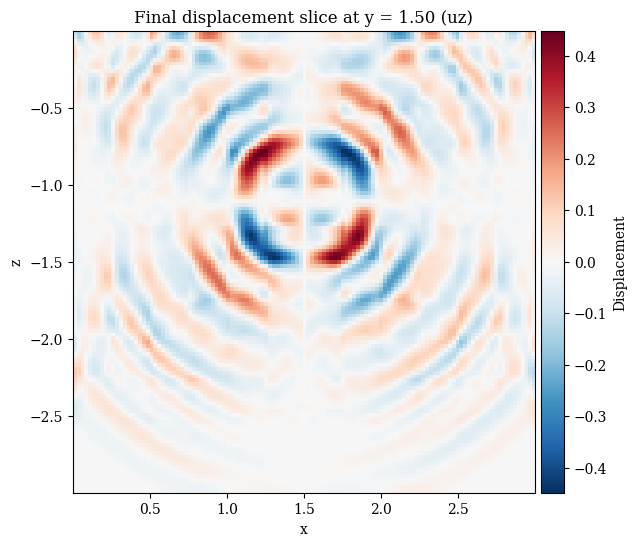

In [22]:
plot_component_slice(wave, component_index=0, y_value=receiver_y, component_name="uz")


The elastic wave equation has one shot record for each direction. The shot record in the $z$ direction is obtained with `out_index=0`; this is the component compared against the vertical SPECFEM3D trace (`BXZ`/`FXZ`, depending on the build).


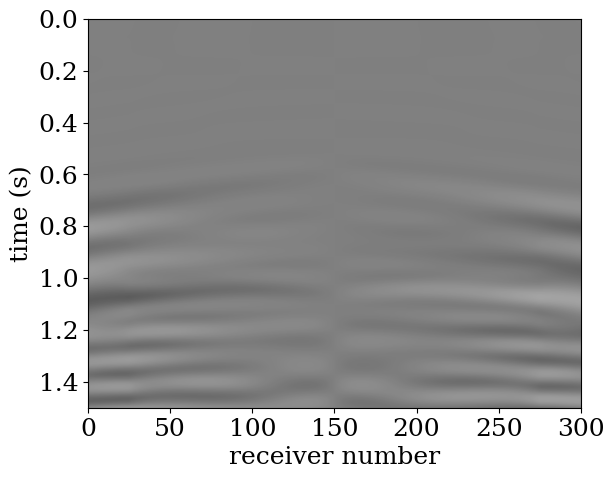

In [23]:
last_displacement = wave.u_n.dat.data_ro.copy()
u_max = np.max(np.abs(last_displacement[:, 0]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=0)


The shot record in the $x$ direction is obtained with `out_index=1`; this is the component compared against the horizontal SPECFEM3D trace (`BXX`/`FXX`).


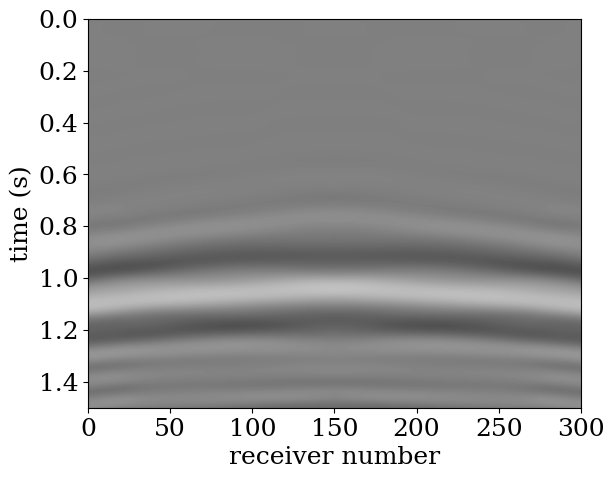

In [24]:
u_max = np.max(np.abs(last_displacement[:, 1]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=1)


Finally, the shot record in the $y$ direction is obtained with `out_index=2`; this is the component compared against the transverse SPECFEM3D trace (`BXY`/`FXY`).


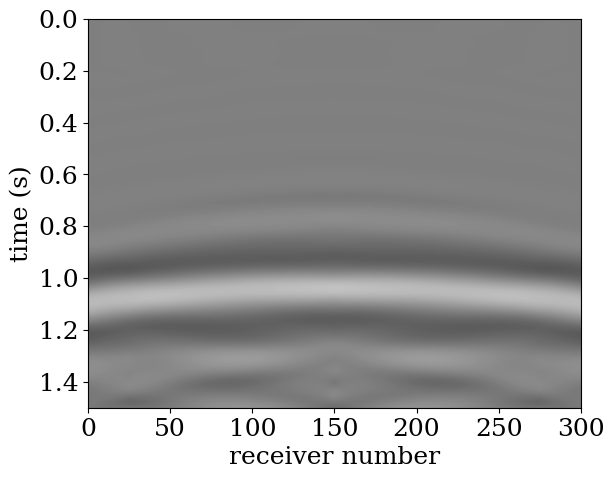

In [25]:
u_max = np.max(np.abs(last_displacement[:, 2]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=2)


In [26]:
receivers_output = np.asarray(wave.receivers_output)
comparison_summary = {
    "coordinate_order": ["z", "x", "y"],
    "component_order": ["uz", "ux", "uy"],
    "cell_type": "hexahedral",
    "edge_length": edge_length,
    "periodic": False,
    "source_receiver_projection": "vertex_only_mesh",
    "mesh_num_cells": int(wave.mesh.num_cells()),
    "mesh_shape": {
        "nx": int(round(dictionary["mesh"]["length_x"] / edge_length)),
        "ny": int(round(dictionary["mesh"]["length_y"] / edge_length)),
        "nz": int(round(dictionary["mesh"]["length_z"] / edge_length)),
    },
    "source_location": dictionary["acquisition"]["source_locations"][0],
    "receiver_start": tuple(receiver_locations[0]),
    "receiver_end": tuple(receiver_locations[-1]),
    "num_receivers": len(receiver_locations),
    "dt": dictionary["time_axis"]["dt"],
    "final_time": dictionary["time_axis"]["final_time"],
    "density": dictionary["synthetic_data"]["density"],
    "vp": dictionary["synthetic_data"]["p_wave_velocity"],
    "vs": dictionary["synthetic_data"]["s_wave_velocity"],
    "source_direction_xyz": tuple(float(value) for value in source_direction_xyz),
    "spyro_amplitude_order_zxy": dictionary["acquisition"]["amplitude"].tolist(),
    "source_delay_requested": source_delay_requested,
    "source_delay_effective": effective_source_delay,
    "source_delay_mode": source_delay_mode,
    "receivers_output_shape": receivers_output.shape,
}
comparison_summary


{'coordinate_order': ['z', 'x', 'y'],
 'component_order': ['uz', 'ux', 'uy'],
 'cell_type': 'hexahedral',
 'edge_length': 0.25,
 'periodic': False,
 'source_receiver_projection': 'vertex_only_mesh',
 'mesh_num_cells': 144,
 'mesh_shape': {'nx': 12, 'ny': 12, 'nz': 12},
 'source_location': (-1.1, 1.5, 1.5),
 'receiver_start': (np.float64(-1.9), np.float64(1.2), np.float64(1.5)),
 'receiver_end': (np.float64(-1.9), np.float64(1.8), np.float64(1.5)),
 'num_receivers': 300,
 'dt': 0.001,
 'final_time': 1.5,
 'density': 0.1,
 'vp': 1.5,
 'vs': 1.0,
 'source_direction_xyz': (0.7071067811865475, 0.7071067811865475, 0.0),
 'spyro_amplitude_order_zxy': [0.0, 0.7071067811865475, 0.7071067811865475],
 'source_delay_requested': 0.2,
 'source_delay_effective': 0.24,
 'source_delay_mode': 'specfem-single-force-ricker',
 'receivers_output_shape': (1501, 300, 3)}

To compare directly against SPECFEM3D, we now export the current Spyro run to `results/spyro_3d`, execute the matching SPECFEM3D case, inspect the assembled SPECFEM parameters and mesh, and then generate the same receiver-comparison figures used in this repository. On the Spyro side, we intentionally keep `VertexOnlyMesh` enabled because source and receiver modeling showed noticeable discrepancies during the 3D comparison work.


In [27]:
import json
import subprocess
from IPython.display import Image, display

spyro_results_dir = project_root / "results" / "spyro_3d"
specfem_results_dir = project_root / "results" / "specfem3d"
comparison_dir = project_root / "results" / "comparison_3d"

spyro_results_dir.mkdir(parents=True, exist_ok=True)
comparison_dir.mkdir(parents=True, exist_ok=True)

spyro_time = np.arange(receivers_output.shape[0], dtype=float) * dictionary["time_axis"]["dt"]
receiver_locations_array = np.asarray(dictionary["acquisition"]["receiver_locations"], dtype=float)
source_locations_array = np.asarray(dictionary["acquisition"]["source_locations"], dtype=float)
source_wavelet = spyro.full_ricker_wavelet(
    dt=dictionary["time_axis"]["dt"],
    final_time=dictionary["time_axis"]["final_time"],
    frequency=dictionary["acquisition"]["frequency"],
    delay=dictionary["acquisition"]["delay"],
    delay_type=dictionary["acquisition"]["delay_type"],
)
mesh_coordinates = wave.mesh.coordinates.dat.data_ro.copy()
mesh_num_cells = int(wave.mesh.num_cells())
mesh_nx = int(round(dictionary["mesh"]["length_x"] / edge_length))
mesh_ny = int(round(dictionary["mesh"]["length_y"] / edge_length))
mesh_nz = int(round(dictionary["mesh"]["length_z"] / edge_length))

np.savez(
    spyro_results_dir / "spyro_receivers.npz",
    time=spyro_time,
    receivers_output=receivers_output,
    receiver_locations=receiver_locations_array,
    source_locations=source_locations_array,
    source_wavelet=source_wavelet,
    mesh_num_cells=mesh_num_cells,
    mesh_coordinates=mesh_coordinates,
)

spyro_metadata = {
    "description": "Notebook-exported reflective 3D Spyro elastic comparison run",
    "coordinate_order": ["z", "x", "y"],
    "component_order": ["uz", "ux", "uy"],
    "spectral_degree": int(dictionary["options"]["degree"]),
    "cell_type": "hexahedral",
    "variant": dictionary["options"]["variant"],
    "periodicity": "none",
    "source_receiver_projection": "vertex_only_mesh",
    "edge_length": float(edge_length),
    "mesh_num_cells": mesh_num_cells,
    "mesh_shape": {"nx": mesh_nx, "ny": mesh_ny, "nz": mesh_nz},
    "source_location": source_locations_array[0].tolist(),
    "receiver_start": receiver_locations_array[0].tolist(),
    "receiver_end": receiver_locations_array[-1].tolist(),
    "num_receivers": int(receiver_locations_array.shape[0]),
    "dt": float(dictionary["time_axis"]["dt"]),
    "final_time": float(dictionary["time_axis"]["final_time"]),
    "frequency": float(dictionary["acquisition"]["frequency"]),
    "source_delay": float(dictionary["acquisition"]["delay"]),
    "source_delay_requested": float(source_delay_requested),
    "source_delay_mode": source_delay_mode,
    "source_direction_xyz": [float(source_dir_x), float(source_dir_y), float(source_dir_z)],
    "density": float(dictionary["synthetic_data"]["density"]),
    "vp": float(dictionary["synthetic_data"]["p_wave_velocity"]),
    "vs": float(dictionary["synthetic_data"]["s_wave_velocity"]),
}
(spyro_results_dir / "spyro_metadata.json").write_text(
    json.dumps(spyro_metadata, indent=2),
    encoding="utf-8",
)

print(f"Saved Spyro notebook outputs to {spyro_results_dir}")


Saved Spyro notebook outputs to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/spyro_3d


We now execute the matching SPECFEM3D case by calling `run_specfem3d.sh`, which lives in the same `notebooks/` directory as this notebook. This keeps the notebook entrypoint local while still forwarding to the repository 3D setup and local `third_party/` solver installation.


In [28]:
specfem_nproc = 1
specfem_cmd = [
    "bash",
    str(notebook_dir / "run_specfem3d.sh"),
    "--edge-length",
    str(edge_length),
    "--nproc",
    str(specfem_nproc),
    "--source-z",
    str(source_z),
    "--source-y",
    str(source_y),
    "--receiver-z",
    str(receiver_z),
    "--receiver-y",
    str(receiver_y),
    "--source-dir-x",
    str(source_dir_x),
    "--source-dir-y",
    str(source_dir_y),
    "--source-dir-z",
    str(source_dir_z),
    "--source-delay",
    str(source_delay_requested),
    "--results-dir",
    str(specfem_results_dir),
    "--log-dir",
    str(project_root / "logs"),
]
print("Running:", " ".join(specfem_cmd))
subprocess.run(specfem_cmd, cwd=notebook_dir, check=True)


Running: bash /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/scripts/run_specfem3d_case.sh --edge-length 0.25 --nproc 1 --source-z -1.1 --source-y 1.5 --receiver-z -1.9 --receiver-y 1.5 --source-dir-x 0.7071067811865475 --source-dir-y 0.7071067811865475 --source-dir-z 0.0 --source-delay 0.2 --results-dir /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/specfem3d --log-dir /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/logs
SPECFEM3D case files written to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/specfem3d_case/DATA
SPECFEM3D mesh files written to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/specfem3d_case/MESH-default

 **********************
 Serial mesh decomposer
 **********************

 reading mesh files in: ./MESH-default

   using NGNOD =            8
   linear elements

 total number of nodes: 
   nnodes =         2197
 total number of spectral elements:
   nspec =         1728
 materials:
   num_mat =            1
   d


Program received signal SIGILL: Illegal instruction.

Backtrace for this error:

Could not print backtrace: executable file is not an executable

Could not print backtrace: executable file is not an executable
#0  0x101262103
#1  0x101261083
#2  0x1834d9763
#3  0x10c1e1b77
#4  0x10c1e6c57
#5  0x18fa33af7
#6  0x18fa3355b
#7  0x18332cad3
#8  0x18332293f
#9  0x18fa3364b
#10  0x18fa33daf
#11  0x18f87c7ef
#12  0x10189e323
#13  0x1018a3e97
#14  0x2276b592f
/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/scripts/run_specfem3d_case.sh: line 161: 84651 Illegal instruction: 4  ./bin/xgenerate_databases
     84652 Done                    | tee "$LOG_DIR/specfem3d_databases.log"


CalledProcessError: Command '['bash', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/scripts/run_specfem3d_case.sh', '--edge-length', '0.25', '--nproc', '1', '--source-z', '-1.1', '--source-y', '1.5', '--receiver-z', '-1.9', '--receiver-y', '1.5', '--source-dir-x', '0.7071067811865475', '--source-dir-y', '0.7071067811865475', '--source-dir-z', '0.0', '--source-delay', '0.2', '--results-dir', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/specfem3d', '--log-dir', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/logs']' returned non-zero exit status 132.

After the run, we print the key SPECFEM3D parameters and mesh information. This makes it explicit that the SPECFEM case uses the same geometry, acquisition layout, material values, and reflective-boundary configuration as the Spyro case. The printed summary also highlights the `VertexOnlyMesh` choice on the Spyro side, because point source/receiver modeling was one of the motivations for this 3D comparison setup.


In [ ]:
from pprint import pprint

specfem_metadata = json.loads(
    (specfem_results_dir / "specfem3d_case_metadata.json").read_text(encoding="utf-8")
)
specfem_timing = json.loads(
    (specfem_results_dir / "timing.json").read_text(encoding="utf-8")
)
num_seismogram_files = len(list((specfem_results_dir / "raw_seismograms").glob("*.semd")))

specfem_run_summary = {
    "specfem3d": {
        "spectral_degree": specfem_metadata["spectral_degree"],
        "ngllx": specfem_metadata["ngllx"],
        "mesh": specfem_metadata["mesh"],
        "material": specfem_metadata["material"],
        "source": specfem_metadata["source"],
        "receivers": specfem_metadata["receivers"],
        "boundary_conditions": specfem_metadata["boundary_conditions"],
        "timing": specfem_timing,
        "num_seismogram_files": num_seismogram_files,
    },
    "matching_checks": {
        "edge_length": bool(np.isclose(specfem_metadata["mesh"]["edge_length"], edge_length)),
        "source_z": bool(np.isclose(specfem_metadata["source"]["z"], source_z)),
        "source_y": bool(np.isclose(specfem_metadata["source"]["y"], source_y)),
        "receiver_z": bool(np.isclose(specfem_metadata["receivers"]["z"], receiver_z)),
        "receiver_y": bool(np.isclose(specfem_metadata["receivers"]["y"], receiver_y)),
        "receiver_count": int(specfem_metadata["receivers"]["count"]) == int(receiver_locations_array.shape[0]),
        "vp": bool(np.isclose(specfem_metadata["material"]["vp"], dictionary["synthetic_data"]["p_wave_velocity"])),
        "vs": bool(np.isclose(specfem_metadata["material"]["vs"], dictionary["synthetic_data"]["s_wave_velocity"])),
        "density": bool(np.isclose(specfem_metadata["material"]["density"], dictionary["synthetic_data"]["density"])),
        "source_direction_xyz": bool(np.allclose(specfem_metadata["source"]["force_direction_xyz"], source_direction_xyz)),
        "periodic": specfem_metadata["boundary_conditions"]["periodic"] is False,
        "absorbing_boundaries": specfem_metadata["boundary_conditions"]["absorbing_boundaries"] is False,
    },
    "comparison_notes": {
        "spyro_source_receiver_projection": "VertexOnlyMesh",
        "vertex_only_mesh_enabled": bool(dictionary["acquisition"].get("use_vertex_only_mesh", False)),
        "why_it_is_emphasized_here": (
            "We keep VertexOnlyMesh enabled because source injection and receiver "
            "sampling/projection were one of the main error-sensitive parts of the "
            "3D comparison. This notebook therefore follows the same point-coupling "
            "strategy used in scripts/run_spyro_elastic_forward_3d.py."
        ),
    },
    "delay_note": {
        "specfem_input_time_shift": specfem_metadata["source"]["time_shift"],
        "spyro_requested_delay": source_delay_requested,
        "spyro_effective_delay_used_above": effective_source_delay,
        "comment": "Spyro uses the effective delay required by the specfem-single-force-ricker mapping, while SPECFEM3D reads the requested 0.2 s shift directly from the input file.",
    },
}
pprint(specfem_run_summary, sort_dicts=False)


With both runs available on disk, we generate and display the same receiver-comparison figures used by the repository comparison script. These figures should be interpreted together with the `VertexOnlyMesh` choice above, because part of the goal is to reduce discrepancies linked to point source/receiver handling rather than to the bulk wave solver alone. This final step is launched with the local notebook-side entrypoint `compare_spyro_specfem3d.sh`.


In [ ]:
import os

compare_cmd = [
    "bash",
    str(notebook_dir / "compare_spyro_specfem3d.sh"),
    "--spyro-dir",
    str(spyro_results_dir),
    "--specfem-dir",
    str(specfem_results_dir),
    "--output-dir",
    str(comparison_dir),
]
print("Running:", " ".join(compare_cmd))
compare_env = dict(os.environ)
compare_env["PYTHON"] = sys.executable
subprocess.run(compare_cmd, cwd=notebook_dir, env=compare_env, check=True)

display(Image(filename=str(comparison_dir / "trace_comparison.png")))
display(Image(filename=str(comparison_dir / "uz_bxz_comparison.png")))
display(Image(filename=str(comparison_dir / "ux_bxx_comparison.png")))
display(Image(filename=str(comparison_dir / "uy_bxy_comparison.png")))
